# Trustworthy Anomaly Agent on ESA-ADB: an end-to-end walkthrough

This notebook runs the **complete pipeline** of the project on real satellite telemetry
(ESA's Mission2, lightweight subset). It detects anomalies, calibrates how much you can
trust each detection, explains which channels caused it, and generates an operator alert
whose text is audited by an LLM judge before it reaches you. Along the way it explains
the **key design decisions** of each module: not just what runs, but *why it is built
this way*. For the project context (the operator's problem, the dataset, the
trustworthiness gap) see the [README](../README.md).

```
Telemetry (Mission2, channels 18-28)
  → [1] Detection      Windowed Isolation Forest         → anomaly score per window
  → [2] Uncertainty    conformal prediction              → calibrated confidence
  → [3] Attribution    channel-level explanation         → which sensors caused it
  → [4] Alert layer    grounded LLM brief + judge        → auditable operator alert
  → [5] This notebook  the whole chain, live
```

**How to use this notebook.** Reading it on GitHub takes about 15-20 minutes and
requires nothing: every output is committed. Running it yourself requires downloading
the dataset once (3.8 GB, instructions below). After the one-time preprocessing
(about 30 minutes) every later run skips the heavy steps automatically.

---
**Data attribution.** ESA Anomaly Dataset (ESA-ADB), © European Space Agency (ESOC),
KP Labs and Airbus Defence and Space, licensed
[CC BY 3.0 IGO](https://creativecommons.org/licenses/by/3.0/igo/).
Dataset: [10.5281/zenodo.12528696](https://doi.org/10.5281/zenodo.12528696) ·
Paper: [arXiv:2406.17826](https://arxiv.org/abs/2406.17826) ·
Code: [kplabs-pl/ESA-ADB](https://github.com/kplabs-pl/ESA-ADB) (MIT), minimally
vendored under `src/` (see `NOTICE`). All results below are traceable to the dataset.
No invented data.


## 0 · Setup & data

The pipeline needs the raw Mission2 telemetry **once**. If you only want to read this
notebook, skip ahead: every cell below is already executed.

1. Download the **ESA-Mission2** folder (3.8 GB) from Zenodo:
   [doi.org/10.5281/zenodo.12528696](https://doi.org/10.5281/zenodo.12528696)
2. Place it at `data/ESA-Mission2/` (so that `data/ESA-Mission2/labels.csv` exists).
3. Run the cells below. The first run preprocesses the raw channels into the
   train/test CSVs (about 30 minutes, one time). Later runs detect the existing
   output and skip the step.

Everything is deterministic: same input, same bytes out, down to the final
F0.5 = 0.9487. There is no hidden state and no cached shortcut in the pipeline itself.


In [1]:
import sys, time, subprocess
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))  # notebook lives in notebooks/
import config

TIMINGS: dict = {}  # wall-clock per heavy step, summarized at the end

RAW_DIR = config.REPO / "data" / "ESA-Mission2"
preprocessed = config.TEST_CSV.exists() and config.TRAIN_CSV.exists()

if preprocessed:
    print(f"[ok] Preprocessed CSVs found — ready.\n     {config.TEST_CSV.name}, {config.TRAIN_CSV.name}")
elif RAW_DIR.exists():
    print("[ok] Raw dataset found — the next cell will preprocess it (~30 min, one-time).")
else:
    raise SystemExit(
        "Dataset not found.\n"
        f"  Expected raw data at:        {RAW_DIR}\n"
        f"  (or preprocessed CSVs at:    {config.PREP_DIR})\n"
        "  Download ESA-Mission2 (~3.8 GB): https://doi.org/10.5281/zenodo.12528696\n"
        "  Then re-run this cell. See section '0 · Setup & data' above."
    )


[ok] Preprocessed CSVs found — ready.
     21_months.test.csv, 21_months.train.csv


In [2]:
# [1a] Raw telemetry -> canonical train/test CSVs (ESA's own prep, vendored — see NOTICE).
# Deterministic: depends ONLY on the immutable Zenodo raw data + preprocessing.py.
# To force regeneration (e.g. after editing the script): delete data/preprocessed_subset/.
if preprocessed:
    print("[skip] Already preprocessed — ~30 min saved.")
else:
    print("[run ] Preprocessing channels 18-28 (~30 min on Apple Silicon)...")
    t0 = time.perf_counter()
    subprocess.run(
        [sys.executable, str(config.REPO / "src" / "m1_detection" / "preprocessing.py"), str(RAW_DIR)],
        check=True,
    )
    TIMINGS["preprocess"] = time.perf_counter() - t0
    print(f"[done] Preprocessing finished in {TIMINGS['preprocess']/60:.1f} min.")


[skip] Already preprocessed — ~30 min saved.


## 1 · Detection: Windowed Isolation Forest

**What runs here.** ESA's own winning detector for this benchmark subset
(`subsequence_if`), executed **verbatim** from the vendored copy in
`src/m1_detection/vendor/algorithm.py`. We *reproduce* the paper's headline number.
Reproduce means: re-run ESA's published experiment with their own code, data and
metric, and land on their number (they report **F0.5 = 0.949**). That number then
doubles as a regression alarm: if any later change moves it, something broke.

**Why a simple forest and not deep learning?** The ESA-ADB paper's own finding: on the
*full* benchmark, every tested detector collapses (F0.5 ≈ 0.07). Nobody, not even the
authors, can tell in advance which detector to trust on which data (the *No Free Lunch*
problem). That is exactly why this project's contribution is the **trust layer**
(modules 2 to 4) rather than yet another detector: an operator facing a bare 0/1 flag
has no way to know when to believe it.


**Step A: train ESA's detector and score the test set.** A sliding window of 17
samples (about 5 minutes of telemetry at 18 s per sample) slides over the 11 channels.
Each window is flattened into one 187-dimensional point. An **Isolation Forest**
(Liu 2008) then tries to isolate each point with random cuts: the fewer cuts needed,
the more anomalous the window. This is the core of ESA's `algorithm.py` (quoted, not
re-implemented):

```python
# src/m1_detection/vendor/algorithm.py (condensed): the entire detection logic
data = sliding_window_view(data, window_shape=17, axis=0).reshape(-1, 17 * n_channels)
clf = IForest(n_estimators=200, random_state=42, ...)
clf.fit(data)                       # train: learn what "normal" looks like
result = clf.predict(data)          # execute: 0/1 per window
result = np.pad(result, 17 // 2)    # window center -> per-point flag
```


In [3]:
from m1_detection import model as m1_model

MODEL_PKL = config.CACHE_DIR / "model.pkl"
SCORES_TEST = config.CACHE_DIR / "scores_test.csv"

if MODEL_PKL.exists() and SCORES_TEST.exists():
    print("[skip] Trained model + test scores found — ~11 min saved.")
    print("       Deterministic (seed=42): retraining reproduces them byte-identically.")
    print("       To force it: delete both files from data/cached/ and re-run.")
else:
    print("[run ] Training Windowed iForest (21 months) + scoring the test set (~11 min)...")
    t0 = time.perf_counter()
    m1_model.main()
    TIMINGS["train+score"] = time.perf_counter() - t0
    print(f"[done] {TIMINGS['train+score']/60:.1f} min.")


[skip] Trained model + test scores found — ~11 min saved.
       Deterministic (seed=42): retraining reproduces them byte-identically.
       To force it: delete both files from data/cached/ and re-run.


**Step B: the official exam.** ESA's event-wise F0.5 metric (`ESAScores`, vendored),
computed exactly as the paper does. The `assert` makes this cell a tripwire: any
future change that breaks the reproduction fails loudly here.


In [4]:
import io, contextlib
from m1_detection import evaluation as m1_eval

with contextlib.redirect_stdout(io.StringIO()):   # ESA's metric prints verbose internals
    result = m1_eval.evaluate()
f05 = result["EW_F_0.50"]
print(f"EW_F_0.50    = {f05:.4f}   (paper Table 2: 0.949)")
print(f"EW_precision = {result['EW_precision']:.4f}")
print(f"EW_recall    = {result['EW_recall']:.4f}")
assert abs(f05 - 0.9487) < 1e-3, "Regression: the pipeline no longer reproduces the paper's number"


EW_F_0.50    = 0.9487   (paper Table 2: 0.949)
EW_precision = 0.9509
EW_recall    = 0.9400


**Step C: see one detection on the real signal.** The longest stretch the detector
flagged, chosen programmatically from its own output. Telemetry in blue, ESA's human
annotation in gray, the detector's flag in red.


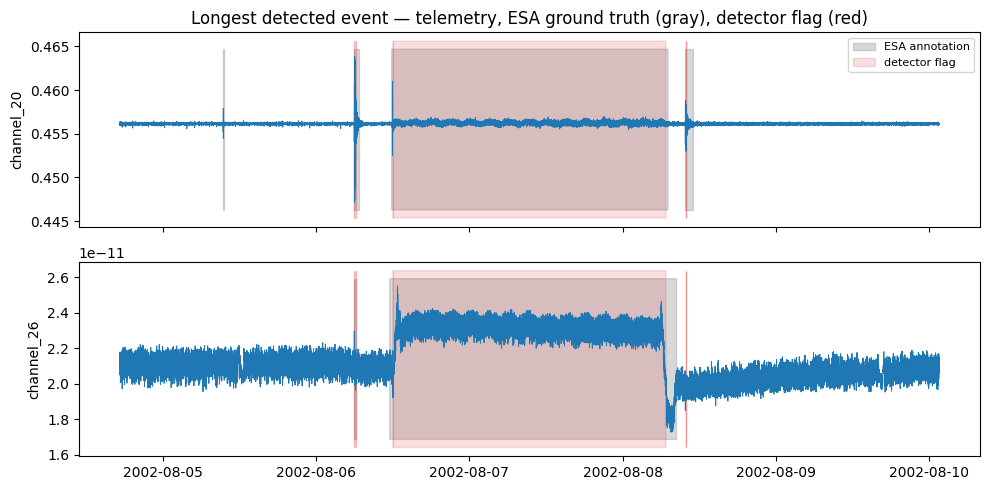

In [5]:
# The detection on real telemetry: longest predicted anomalous stretch, chosen
# programmatically from the detector's own output (no hand-picked indices).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

flags = np.loadtxt(SCORES_TEST, delimiter=",")            # detector 0/1 per test point
edges = np.flatnonzero(np.diff(np.r_[0, flags, 0]))       # run boundaries
starts, ends = edges[::2], edges[1::2]
k = int(np.argmax(ends - starts))                         # longest predicted event
pad = ends[k] - starts[k]
lo, hi = max(0, starts[k] - pad), min(len(flags), ends[k] + pad)

seg = pd.read_csv(config.TEST_CSV, skiprows=range(1, lo + 1), nrows=hi - lo)
seg["timestamp"] = pd.to_datetime(seg["timestamp"])
pred = flags[lo:hi].astype(bool)

# plot the two channels with the most annotated anomaly in this stretch
anno_cols = [f"is_anomaly_{c}" for c in config.TARGET_CHANNELS]
top2 = (seg[anno_cols] > 0).sum().nlargest(2).index
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, col in zip(axes, top2):
    ch = col.replace("is_anomaly_", "")
    truth = (seg[col] > 0).to_numpy()
    ax.plot(seg["timestamp"], seg[ch], lw=0.7, color="tab:blue")
    ax.fill_between(seg["timestamp"], *ax.get_ylim(), where=truth,
                    color="gray", alpha=0.3, label="ESA annotation")
    ax.fill_between(seg["timestamp"], *ax.get_ylim(), where=pred,
                    color="tab:red", alpha=0.15, label="detector flag")
    ax.set_ylabel(ch)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Longest detected event — telemetry, ESA ground truth (gray), detector flag (red)")
plt.tight_layout()
plt.show()


### Why it is built this way: design decisions

1. **Vendor, never re-implement.** The detector, the preprocessing and the metric are
   ESA's own files, byte-identical (see `NOTICE`). Reproducing 0.949 with their code is
   *evidence*; re-implementing it would only prove we can introduce bugs.
2. **`subsequence_if` is the *standard* Isolation Forest**, not the Extended variant.
   ESA also ships `subsequence_eif` (one letter away, a different algorithm, not used
   in this benchmark). Documented because the confusion is expensive.
3. **Verify the data before trusting any result.** The preprocessing output was checked
   against ESA's shipped metadata (grid lengths, anomaly lengths, split boundaries: 6
   external checks, see [docs/REPRODUCTION.md](../docs/REPRODUCTION.md)) *before*
   running any detector.
4. **Detector-agnostic by construction.** Modules 2 to 4 consume only the detector's
   *outputs* (a continuous score per window, the windowed data, a scoring function),
   never its internals. Swapping in a different detector, for example ESA's deep
   DC-VAE, means regenerating those artifacts, not rewriting the trust layer.

**One limitation drives the next section:** `predict()` emits a hard 0/1. It says
*"anomaly"* with the same face whether it is 99% sure or 51% sure. For an operator that
difference is everything. Quantifying it is Module 2's job.


## 2 · Uncertainty: from raw score to calibrated confidence

**The problem.** The detector's 0/1 flag, and even its internal score, says nothing an
operator can act on. The Isolation Forest score only *orders* windows by rarity, on an
arbitrary scale: it is not a probability, and "score = 0.13" means nothing by itself.

**The idea.** Instead of trusting the raw score, compare it against a reference of
known-normal behavior: how does this window rank among windows we are sure were normal?

**The tool: conformal p-values.** Take a large pool of windows known to be normal
(the *calibration set*) and score them all. For a new window with score $s$:

$$p = \frac{\#\{\text{calibration scores} \geq s\} + 1}{n_{\text{calib}} + 1}$$

Read it as: *"what fraction of certified-normal history looks at least this weird?"*
If the data are exchangeable (roughly: the normal calibration windows and the new
ones come from the same behavior), this p-value comes with a **distribution-free
guarantee**:
flagging when $p < \alpha$ produces at most an $\alpha$ rate of false alarms on normal
data, regardless of what the detector is or how the data are distributed. So α stops
being a magic threshold and becomes a **false-alarm budget** you choose. Note that the
p-value itself makes **no decision**: it is a threshold-free rank, and every window
gets one. No cut exists until α is chosen, three cells below.


**Step A: get the raw material.** M1's `predict()` is a binary, and a binary cannot be
calibrated (a yes/no has no degrees). But the forest internally holds a continuous
score (`decision_function`: how hard each window was to isolate). This cell re-scores
all ~3M test windows with the **same trained forest**, with no retraining. Its check
proves the scores are trustworthy: thresholding them at M1's internal cut gives back
M1's exact 0/1.


In [20]:
from m2_uncertainty import scores as m2_scores
import numpy as np

SCORES_CONT = config.CACHE_DIR / "scores_continuous.npy"

if SCORES_CONT.exists():
    print("[skip] Continuous scores found. To recompute: delete the file and re-run.")
    cont = np.load(SCORES_CONT)
else:
    print("[run ] Scoring all test windows with the M1 forest (decision_function)...")
    t0 = time.perf_counter()
    cont = m2_scores.compute_scores()
    m2_scores.verify(cont)   # incl.: thresholding these gives M1's exact 0/1 back
    np.save(SCORES_CONT, cont)
    TIMINGS["continuous_scores"] = time.perf_counter() - t0
    print(f"[done] {TIMINGS['continuous_scores']/60:.1f} min.")
print(f"{len(cont):,} window scores — continuous, ready to calibrate.")


[skip] Continuous scores found. To recompute: delete the file and re-run.
3,062,385 window scores — continuous, ready to calibrate.


**Step B: put every window on a calibrated scale.** Two moves, and *neither involves a
threshold, a model decision, or any α*. First the **split**: the test period is cut in
three chronological thirds (calibration / validation / final report), and windows are
marked "certified normal" purely from **ESA's human annotations**. Then **conformal**:
each window's score becomes its p-value, a rank against the 57k-window calibration
pool. Every window gets its "rarity percentile"; nothing is flagged yet.


In [21]:
from m2_uncertainty import split as m2_split, conformal as m2_conformal

t0 = time.perf_counter()
m2_split.build()             # thirds + normal-window mask + 1-of-17 selection
s = m2_conformal.build()     # calibration set + p-values (validation + test-final)
m2_conformal.verify(s)       # p in [0,1], hand-example exact, ~5% below 0.05
TIMINGS["split+conformal"] = time.perf_counter() - t0
print(f"[done] split + conformal p-values in {TIMINGS['split+conformal']:.0f} s.")


Split cached -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/split.npz
Calibration set -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/calib_scores.npy  (n=57735)
p (valid)       -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_valid.npy  (n=1020800)
p (test-final)  -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_test.npy  (n=1020793)

=== Phase 3 success-test ===
  (a) p in [0,1]       : [0.0000, 1.0000]  OK
  (b) monotone         : p decreasing in score  OK
  (c) hand example     : p(0.35 | [.1...5]) = 0.5000 == 0.5  OK
  (d) coverage (indep) : P(p<0.05) = 0.0486  (target 0.05, 95% CI [0.0475, 0.0525], n=28867)
      -> within CI: conformal math sound on same-epoch normals  OK
[done] split + conformal p-values in 5 s.


**Step C: choose where the alarm line goes.** Two things happen here. The **rolling**
variant recalibrates causally per block, because a fixed calibration ages (the
satellite of month 18 is not the satellite of month 1). And the **α tuning** sweeps a
grid of candidate alarm lines over the *validation* third, measuring event-wise F0.5
at each point, for both variants. This is the only optimization in the module, and it
happens *after* the p-values exist, never before.


In [ ]:
import io, contextlib
from m2_uncertainty import rolling as m2_rolling, alpha as m2_alpha

t0 = time.perf_counter()
m2_rolling.build()           # causal recalibration (drift countermeasure)
with contextlib.redirect_stdout(io.StringIO()):   # grid search calls ESA's chatty metric
    a = m2_alpha.build()     # tune alpha on validation (F0.5), both variants
    m2_alpha.verify(a)
TIMINGS["rolling+alpha"] = time.perf_counter() - t0

a_star = a["a_fixed"] if a["winner"] == "fixed" else a["a_roll"]
print(f"[done] rolling + alpha tuning in {TIMINGS['rolling+alpha']/60:.1f} min.")
print(f"Winner variant: {a['winner']}   alpha* = {a_star:.1e}")
print(f"F0.5 at alpha* (validation): {max(a['best_fixed'], a['best_roll']):.3f}")


rolling p (valid)      -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_valid_rolling.npy  (n=1020800)
rolling p (test-final) -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_test_rolling.npy  (n=1020793)


**Step D: the final exam.** The final split (third 3) has been touched by no decision so
far. It is used exactly once. Before the numbers, what each one means:

- **Precision**: of the windows we flagged, how many were truly anomalies. High means
  few false alarms.
- **Recall**: of the real anomalies, how many we caught. High means few misses.
- **F0.5**: a single score combining the two, weighting **precision twice as much** as
  recall. This is ESA's benchmark score.
- **F2**: the same combination, weighting **recall twice as much**. The "miss nothing"
  face of the same result. We report it next to F0.5 so both sides are visible.

One more number matters: at our actual operating point α*, how often do we raise a
false alarm on data we *know* is normal? The conformal method bounds it, and here we
measure it directly on the final third.


In [ ]:
import io, contextlib
import numpy as np
from m2_uncertainty import evaluate as m2_evaluate

# Final report on the untouched third (captured: ESA's metric is verbose).
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    m2_evaluate.evaluate()
report = buf.getvalue()
print(report[report.index("================ M2 FINAL REPORT"):report.index("=== Phase 5")])

# False alarms at our real operating point alpha*, on windows we KNOW are normal.
split = np.load(config.CACHE_DIR / "split.npz")
thirds, normal = split["window_third"], split["window_normal"]
alpha_star = float(np.load(config.CACHE_DIR / "alpha_choice.npz")["alpha_fixed"])
p_norm = np.load(config.CACHE_DIR / "p_test.npy")[normal[np.flatnonzero(thirds == 2)]]
false_alarms = int((p_norm < alpha_star).sum())
print(f"At the operating point alpha* = {alpha_star:.0e}:")
print(f"  {false_alarms} false alarms across {p_norm.size:,} known-normal windows (final third).")


### Why it is built this way: design decisions

1. **Calibration must be clean, and we pay for it honestly.** The forest trained on
   the train period, so calibrating there would be biased (in-sample). Hence the
   test-period split you just saw. Chronological means zero leakage, but calibration
   and test then live in different epochs of the satellite, so drift weakens the
   guarantee. We do not assume it holds: we **measure it** (Step B: 4.86% ≈ the 5%
   promise). Drift only bites near that 5% budget, though. Since we actually operate far
   below it (α* ≈ 2e-5), drift never reaches our operating point, which is why Step D
   shows **zero** false alarms there. A rolling recalibration was built as insurance for
   anyone operating at the 5% guarantee; at the F0.5 point the fixed one already wins.
2. **Overlapping windows lie about sample size.** Neighboring windows share 16 of 17
   points; they are near-copies. Calibrating on all of them would fake a huge
   calibration set. We keep **1 window of every 17** (the independent ones): fewer,
   but honest.
3. **TWO alphas, because two jobs. And α is a consequence of your metric, not a
   physical truth.** The *guarantee* α (5%) controls false alarms per window; marking
   5% of ~3M windows means thousands of false events, so F0.5 ≈ 0. The benchmark
   instead scores per-event F0.5, which **weighs precision double**: every false event
   is expensive, so the optimizer only lets the most extreme windows fire. That is
   *why* α* sank to the p-value floor (≈ 2e-5) in Step C. Optimize F2 (recall-weighted)
   instead and α* rises: recall goes from 0.95 to 0.98, but precision collapses from
   0.85 to 0.61. Same p-values, different alarm line. **The metric you optimize
   chooses your α for you.** And the F0.5 point is strong, not degenerate: precision
   0.85 AND recall 0.95 on validation, flagging only 1.25% of windows. One number
   cannot do both jobs; pretending it can would be lying with statistics.
4. **F0.5 weighs precision double, but a missed anomaly usually hurts more than a
   false alarm.** We optimize F0.5 anyway, for two reasons: comparability with ESA's
   benchmark, and false-alarm fatigue is real (ignored alerts become missed anomalies
   via the human). But the report shows recall and F2 *next to it*, so the operator
   sees both faces and can slide α to their own operating point.
5. **Confidence means "false-alarm control", never "probability of anomaly".** A
   one-class detector cannot give P(anomaly) without a base rate. $1-p$ is confidence
   in rejecting "this is normal". We claim less, and what we claim is true.

**What the next section adds:** the alert now says *how much* to trust it, but not
*where to look*. Pointing at the responsible channels is Module 3's job.


## 3 · Attribution: which channels caused it

**The problem.** Module 2 tells the operator *how much* to trust an alarm, but not
*where to look*. With 11 channels (hundreds in a real mission) a bare "anomaly here"
still means opening every plot. Attribution answers: which sensors drove this detection?

**The tool: perturbation.** No new model, no SHAP. For a flagged window we ask the
detector a counterfactual, one channel at a time: *"if this channel had behaved
normally, how much less anomalous would you find this window?"* We replace the channel
with its normal baseline, re-score, and measure the drop. A big drop means that channel
carried the anomaly. This is the whole method, quoted from the module:

```python
# src/m3_attribution/attribute.py: contribution of each channel c
base = clf.decision_function(windows)          # anomaly score as-is
for c in range(11):
    pert = windows.copy()
    pert[:, c*17:(c+1)*17] = baseline[c]        # channel c -> its normal value
    contrib[:, c] = base - clf.decision_function(pert)   # how much c mattered
```

It is model-agnostic (it only calls `decision_function`, so it survives a detector
swap) and it catches *collective* anomalies, where no single channel is extreme but the
combination is impossible, which a raw-magnitude ranking misses.


**Step A: build the normal baseline.** The value each channel is reset to during
perturbation: the median per channel over the *normal* points of the calibration third (third 1).
A real, robust normal level, not zero.


In [ ]:
from m3_attribution import baseline as m3_baseline
import numpy as np

BASELINE_NPY = config.CACHE_DIR / "m3_baseline.npy"
if BASELINE_NPY.exists():
    print("[skip] Baseline found. To recompute: delete data/cached/m3_baseline.npy.")
    base = np.load(BASELINE_NPY)
else:
    t0 = time.perf_counter()
    base = m3_baseline.compute_baseline()
    np.save(BASELINE_NPY, base)
    m3_baseline.verify(base)
    TIMINGS["m3_baseline"] = time.perf_counter() - t0
print(f"Normal baseline ready: one level per channel, shape {base.shape}.")


**Step B: attribute every flagged window, then group into events.** Perturb each marked
window channel-by-channel (11 channels in one batched call), then group the marked
windows into events. The grouping gap (100 windows ≈ 30 min) is tuned so the count of
predicted events matches the real ones almost exactly. Output: one channel ranking per
event, which is what the operator triages.


In [ ]:
from m3_attribution import aggregate as m3_aggregate

t0 = time.perf_counter()
events = m3_aggregate.build(gap=100)   # perturb marked windows + group into events
m3_aggregate.verify(events, gap=100)
TIMINGS["m3_attribute"] = time.perf_counter() - t0
print(f"\n{len(events)} events, each with a per-channel attribution ranking.")


**Step C: does the attribution actually work?** The honest test. Against the per-channel
ground truth (`is_anomaly_channel_*`), how often is the top-ranked channel a true
culprit (hit@1), and how good are the top 3 (precision@3)? Compared head to head against
two baselines: ranking channels by raw magnitude, and random. This is where the method
earns its place or does not.


In [ ]:
from m3_attribution import evaluate as m3_evaluate

res = m3_evaluate.build()
m3_evaluate.verify(res)   # HARD: perturbation must beat random; vs magnitude reported honestly


**Step D: see one event.** A heatmap of channel contribution over time for a
representative event, with the true culprits marked. A sanity check you can read at a
glance: the hottest channel in the figure is the ranking's #1.


In [ ]:
from m3_attribution import visualize as m3_visualize
from IPython.display import Image, display

res = m3_visualize.build()          # heatmap channel x time for a representative event
m3_visualize.verify(res)
display(Image(filename=str(m3_visualize.OUT_PNG)))


**Step E: assemble the grounded package for Module 4.** For each event, `context.build`
bundles exactly what the LLM is allowed to see: the M2 confidence, the ranked channels,
and their *relative* metadata relations (shared unit or group). No free text, every
field on a whitelist. This JSON is the handoff: the LLM writes from it, the judge audits
against it.


In [ ]:
from m3_attribution import context as m3_context

contexts = m3_context.build()       # grounded per-event package for Module 4
m3_context.verify(contexts)
top = contexts[0]                   # highest priority first
print("\nHighest-priority event, packaged for Module 4:")
print(f"  event #{top['event_id']}  ({top['duration_sec']/3600:.1f} h, {top['n_windows']} windows)")
print(f"  M2 confidence : {top['m2_confidence']:.4f}   priority: {top['priority']:.3f}   ({top['localization']})")
print(f"  top channels  : {[c for c, _ in top['top_channels'][:3]]}")
print(f"  dominant      : {top['dominant_channels']}")
print(f"  shared hardware: {top['shared_relations']}")


### Why it is built this way: design decisions

1. **Perturbation, not SHAP or magnitude.** Model-agnostic (respects the
   detector-agnostic seam), CPU, no new dependencies, and unlike ranking by raw
   deviation it captures *collective* anomalies where no single channel is extreme but
   the combination is impossible. The validation above proves it: perturbation hit@1
   near 1.0 versus magnitude near 0.62.
2. **Baseline = median of real normal windows**, not zero and not a flat constant.
   Flattening a channel to a constant kills its variance, and a dead-flat line can look
   anomalous for its own reason, poisoning the measurement. Using a real normal level
   avoids that (a documented risk, checked in the module's `verify`).
3. **Attribute per window, aggregate to event.** The operator triages events, and ESA's
   metric is event-wise, so per-window attribution is summed into a per-event channel
   profile.
4. **Anonymized channels, so relative grounded hypotheses only.** The channel metadata
   is anonymized (subsystem_1, group_2, ...), so Module 3 prepares *relative* context
   ("channels 22 and 23 share physical_unit_9, so a coupled fault is plausible"), never
   an absolute cause. Module 3 only assembles grounded context; the LLM writes and the
   judge audits, in Module 4.

**What the next section adds:** we now have, per event, a calibrated confidence (M2) and
a ranked list of responsible channels with their shared-hardware relations (M3).
Module 4 turns that evidence into a readable operator brief, and a second LLM judges it
against the very same evidence, blocking anything not grounded.


## 4 - Trustworthy alert: grounded brief + LLM judge

This is the differentiator. Detection, uncertainty and attribution are now in hand; the
job of this layer is to turn that evidence into something an operator can read, without
letting a language model invent anything.

The design is **two moments, two tools**:

1. **The event OPENS.** Only its first flagged window exists. Reasoning would be
   premature and the downlink budget is tiny, so the alert is a **deterministic template**
   over that one window: no model, no retrieval, sent immediately.
2. **The event CLOSES.** Now the full picture exists (duration, every channel, the
   aggregated attribution from Module 3). There is time to reason, so this alert is a
   **retrieval plus a single generated paragraph, audited by a second model**.

Two rules make it trustworthy. The language model generates exactly **one thing**, the
prose paragraph: every number stays in deterministic tables built verbatim from Modules
2 and 3, so there is nothing for the model to fabricate. And the paragraph must clear
**two guardrails in series**: a lexical precheck (deterministic) and an LLM judge
(semantic). The verdict is the AND of both.

We walk one event end to end (event 33, the highest-priority one), then measure the
judge against a labelled golden set.

**Step A: one event through its two moments.** We follow event 33 across its lifecycle.
When it **opens**, only its first flagged window exists, so the START flag is a
deterministic template over that window: sent immediately, no model, no retrieval. When
it later **closes**, Module 3's aggregated package exists (duration, every channel, the
dominant ones), and that fuller picture is what the reasoning at close will use. The two
cells below show each moment: the opening flag, then the closed event.

In [38]:
from m4_report import start_window, alert

EVENT_ID = 33  # the highest-priority event; used as the worked example through Module 4

# First-window attribution: time-cost only, so it is generated on your machine once and
# reused (the Module 1 pattern). Delete the file to force a rebuild.
if not start_window.START_JSON.exists():
    print("building first-window attribution (needs model.pkl; ~seconds)...")
    start_window.build()
else:
    print(f"[skip] first-window records already built ({start_window.START_JSON.name}); delete to force")

records = alert.load_start_windows()
flag = alert.start_flag(records[EVENT_ID])

print("\nMOMENT ONE, the event opens. START flag (deterministic template, no LLM):")
print("  " + alert.render_flag(flag))
print(f"\nflag channels come from the FIRST window only: {flag['channels']}")

[skip] first-window records already built (m4_start_windows.json); delete to force

MOMENT ONE, the event opens. START flag (deterministic template, no LLM):
  ANOMALY START t=2002-12-31T05:13:12 | ch 20,18,19 | intensity high (score 0.002) | conf>0.9999 (saturated)

flag channels come from the FIRST window only: ['channel_20', 'channel_18', 'channel_19']


In [39]:
from m4_report.generation.generator import load_contexts
from m4_report import prompts

contexts = {c["event_id"]: c for c in load_contexts()}   # Module 3's closed-event packages
ctx = contexts[EVENT_ID]
all_flagged = [c for c, _ in ctx["top_channels"]]

print(f"MOMENT TWO, the event has closed. Now the full picture exists:")
print(f"  duration     : {prompts.human_duration(ctx['duration_sec'])}  ({ctx['n_windows']} windows)")
print(f"  all channels : {all_flagged}")
print(f"  dominant     : {ctx['dominant_channels']}")
print(f"  localization : {ctx['localization']}   priority: {ctx['priority']:.2f}")
print(f"\ncontrast with moment one: the flag saw only {flag['channels']} (first window).")
print("the aggregated view is richer and different, proof the flag used no future information.")

MOMENT TWO, the event has closed. Now the full picture exists:
  duration     : 30 h 52 min 48 s  (6161 windows)
  all channels : ['channel_18', 'channel_23', 'channel_22', 'channel_21', 'channel_24', 'channel_20', 'channel_19']
  dominant     : ['channel_18', 'channel_23', 'channel_22', 'channel_21']
  localization : confident   priority: 1.45

contrast with moment one: the flag saw only ['channel_20', 'channel_18', 'channel_19'] (first window).
the aggregated view is richer and different, proof the flag used no future information.


**Step B: retrieve similar past anomalies.** Only at close, with the full channel set in
hand, we match the event against a corpus of 644 past anomalies using a weighted Tversky
index (a set-overlap score), with no embeddings and no vector database: the whole
retrieval is explainable arithmetic. Two safeguards. It considers only past anomalies
that **ended before this event started**, so it characterises what the event resembles
without ever peeking at its own label. And it reports **novelty**, how unlike anything in
the archive the channel combination is, as an honest signal rather than a hidden score.

In [40]:
from m4_report.retrieval import retrieve as m4_retrieve

# load_corpus() builds m4_anomaly_corpus.json from labels.csv on first call, then reuses it.
corpus = m4_retrieve.load_corpus()
result = m4_retrieve.retrieve(ctx, corpus)   # weighted Tversky over channel sets; live arithmetic

print(f"combination novelty: {result['novelty']:.3f}   (0 = seen before, 1 = unlike anything past)")
print("closest past anomalies (all ended before this event started):")
for nb in result["neighbors"][:3]:
    print(f"  {nb['id']}  similarity={nb['sim']:.3f}  class={nb['class']}  category={nb['category']}")

combination novelty: 0.102   (0 = seen before, 1 = unlike anything past)
closest past anomalies (all ended before this event started):
  id_638  similarity=0.898  class=class_22  category=Rare Event
  id_326  similarity=0.800  class=class_23  category=Rare Event
  id_116  similarity=0.769  class=class_19  category=Rare Event


**Step C: the single generated paragraph.** The model receives only narrative-shaped
evidence: names (channels, groups, physical units), qualitative words, a human-readable
duration and a confidence percentage. Precise measurements never reach it, so it cannot
alter them; they live in the tables. Note where retrieval enters: the evidence carries
only the qualitative word from Step B (here "familiar"), never the neighbor ids or
similarities, which stay in the similar-anomalies table. The brief is the one thing the
language model produces.

In [41]:
from m4_report import prompts

# The ONLY material the model sees, shown in full. The "archive" block at the end is the
# only place Step B's retrieval enters, and only as the qualitative word "familiar"; the
# neighbor ids and similarities stay out (they live in the tables).
evidence = prompts.evidence_block(ctx, result)
print("EVIDENCE handed to the model (names and words only, no precise numbers):\n")
print(evidence)

EVIDENCE handed to the model (names and words only, no precise numbers):

EVIDENCE (use ONLY these facts):
{
  "event": {
    "status": "closed -- the detector stopped flagging windows (says nothing about the underlying issue being resolved)",
    "localization": "confident",
    "dominant_channels": [
      "channel_18",
      "channel_23",
      "channel_22",
      "channel_21"
    ],
    "all_flagged_channels": [
      "channel_18",
      "channel_23",
      "channel_22",
      "channel_21",
      "channel_24",
      "channel_20",
      "channel_19"
    ],
    "coupling_note": "hypothesis (unconfirmed): channel_23, channel_22, channel_21 share group_2 (group); channel_23, channel_22, channel_21 share physical_unit_9 (unit) -- a coupled behaviour is possible",
    "duration": "30 h 52 min 48 s",
    "confidence": "99.998 %",
    "confidence_note": "confidence is saturated (near its ceiling) across ALL flagged events; it does not rank or discriminate between events -- use the priority

**Choose how the brief is produced, before generating it.** By default the next cell
reads the committed LLM cache (`ESA_LLM_USE_CACHE` is true), so the brief reproduces
exactly with no API key. The cache is not about saving money (the model is free to run):
a language model is not bit-deterministic even at temperature zero, so the committed
response is the canonical reference. To generate live against Groq instead, uncomment the
cell below now (a live re-roll may differ slightly from the cached reference, which is
expected). Leave it as is to stay offline.

In [ ]:
# OPTIONAL: generate the brief live instead of reading the committed cache. Run this
# BEFORE the next cell.
# 1. Get a free API key at https://console.groq.com
# 2. Put it in .env as GROQ_API_KEY, then uncomment:
#
# import os
# os.environ["ESA_LLM_USE_CACHE"] = "false"

In [42]:
import textwrap
from m4_report.generation.generator import generate_brief

# The single LLM output, honoring the mode chosen above. A lexical precheck runs inside
# generate_brief and raises on any fabricated token. Wrapped so it fits the console.
brief = generate_brief(ctx, result)
print("BRIEF (the one generated paragraph, precheck already passed):\n")
print(textwrap.fill(brief, width=88))

BRIEF (the one generated paragraph, precheck already passed):

The event is now closed -- the detector stopped flagging windows (says nothing about the
underlying issue being resolved). Localization is confident and the dominant channels
are channel_18, channel_23, channel_22, and channel_21. All flagged channels include
channel_18, channel_23, channel_22, channel_21, channel_24, channel_20, and channel_19.
hypothesis (unconfirmed): channel_23, channel_22, channel_21 share group_2 (group);
channel_23, channel_22, channel_21 share physical_unit_9 (unit) -- a coupled behaviour
is possible. The anomaly persisted for 30 h 52 min 48 s with a confidence of 99.998 %;
confidence is saturated (near its ceiling) across ALL flagged events; it does not rank
or discriminate between events -- use the priority value in the facts table. The channel
combination is familiar; derived deterministically from how much this event's CHANNEL
COMBINATION matches past anomalies; it says nothing about magnitude o

**Step D: two guardrails in series.** The brief only ships if it clears both, so the
verdict is their AND. They catch different failures, so each has its own cell below.

- **Guardrail 1, precheck (lexical, deterministic, no model).** Every citable token in
  the brief (a channel, a past-anomaly id, a number, a timestamp) must appear literally
  in the evidence. It is free and exact, and it already ran inside Step C. It cannot see
  a hallucination that invents no token.
- **Guardrail 2, judge (semantic, a second model).** It audits the brief claim by claim
  against the same evidence, told to refute. It catches what the precheck cannot: a
  stated root cause, a hypothesis sold as fact, an overclaim of certainty, a
  "resembles a thermal fault" with no false token. PASS and FLAG ship the brief; BLOCK
  withholds it.

In [43]:
from m4_report.guardrails.precheck import precheck

# Guardrail 1 on the real brief: it passes (nothing cited that is not in the evidence).
print("precheck on the real brief:", precheck(brief, evidence))

# Inject a fabricated channel that is nowhere in the evidence: the precheck names it.
fabricated = brief + " channel_99 also fired."
print("precheck with a fabricated channel_99:", precheck(fabricated, evidence))

precheck on the real brief: {'passed': True, 'offending': []}
precheck with a fabricated channel_99: {'passed': False, 'offending': ['channel_99']}


In [44]:
from m4_report.guardrails.judge import judge
from m4_report.evals.run_eval import run as run_golden

# Guardrail 2 on the real brief: fully grounded, so it passes.
verdict = judge(brief, evidence)
print(f"judge verdict on event {EVENT_ID}: {verdict.verdict}")
print(f"  reasons: {verdict.reasons or 'none (every claim grounded in the evidence)'}")

# Who watches the watchman: the judge golden (clean must pass, dirty must block). Cached.
g = run_golden()
print(f"\njudge golden: precision {g['precision']:.2f} (clean approved), "
      f"recall {g['recall']:.2f} (dirty blocked)")
print(f"  over {g['n_clean']} clean + {g['n_dirty']} dirty hand-labelled cases")
print("\nsample hallucinations the judge blocks (invisible to the precheck):")
for r in g["results"]:
    if r["expected"] == "BLOCK" and r["id"] in ("D2", "D5", "D9"):
        print(f"  [{r['id']}] {r['got']}: {r['tests'][:62]}")

judge verdict on event 33: PASS
  reasons: none (every claim grounded in the evidence)

judge golden: precision 1.00 (clean approved), recall 1.00 (dirty blocked)
  over 7 clean + 11 dirty hand-labelled cases

sample hallucinations the judge blocks (invisible to the precheck):
  [D2] BLOCK: semantic hallucination with NO false token (the judge's reason
  [D5] BLOCK: leakage: cites a past anomaly that is not in the evidence
  [D9] BLOCK: resolution claim (closed means only that flagging stopped)


### Why it is built this way: design decisions

Told in the order the system actually runs.

1. **Two moments, two tools.** A dumb fast template the instant the event opens (latency
   zero, tiny downlink, no future information); a reasoned brief only at close, when the
   full picture exists. Reasoning early would be premature and would leak the event's own
   future into the opening alert.
2. **At close, retrieval is deterministic, not a vector database.** A weighted Tversky
   index over channel sets: explainable, reproducible, edge-friendly, auditable, and
   restricted to past anomalies that ended before the event (anti-leakage). A vector
   database is noted as future work for free-text knowledge (manuals, procedures).
3. **The model only narrates; every number is deterministic.** The design target is a
   small model running on board, so instead of buying a bigger model we shrink the
   probabilistic surface: the prose is simplified to the minimum and all figures live in
   verbatim tables, never passing through the model. The few qualitative words
   ("familiar", the readable duration, the coupling sentence) are computed by fixed rules
   and the model only repeats them. Tradeoff accepted: less rich prose in exchange for
   prose that cannot lie.
4. **Channels are anonymized, so the brief offers relative coupling hypotheses, never a
   root cause.** The dataset gives no channel semantics, so the system cannot and must
   not diagnose a cause. It states only what shared hardware allows ("these channels
   share a group, a coupled fault is possible"), always labelled as an unconfirmed
   hypothesis.
5. **Confidence is reported as saturated, never sold as discriminating.** It sits near
   its ceiling for every flagged event (the alpha* floor from Module 2), so the brief
   says so and points to priority instead. The judge blocks any certainty overclaim.
6. **The prompt is versioned and event-blind.** No event-specific data ever enters the
   prompt, only system vocabulary, and a shipped prompt version is never edited. The
   generator was hardened on a held-out set: a minimal "quote, do not paraphrase" fix
   took the run from 116/120 to 120/120 without breaking the ones that already passed.
7. **Two guardrails in series, verdict is the AND.** A lexical precheck (free, catches
   fabricated tokens and numbers) then an LLM judge (catches semantic hallucination with
   no false token). Neither alone is enough.
8. **The judge is evaluated before it is trusted.** A golden set of 18 diverse
   human-labelled cases (7 clean it must pass, 11 dirty covering each violation type)
   gives precision 1.0 and recall 1.0. Declared as an existence proof over 18 cases, not
   a statistical guarantee.
9. **The committed cache is a reproducibility device, not a cost saver.** The model is
   free to run, but it is not bit-deterministic even at temperature zero, so the frozen
   response is the canonical reference. Anyone can regenerate live with a key; the
   time-only artifacts regenerate on the user's machine on first run and are then reused.

**What the next section adds:** here we dissected one event statically. The streaming
simulation replays the whole mission timeline in order, with no lookahead, firing these
two moments as events open and close, and reports the downlink reduction (and the
generator's PASS/FLAG/BLOCK scorecard over all 120 events) that makes the layer worth
putting on board.

## 5 · Live streaming simulation

*(section coming in Fase 7)*

## 6 · Wrap-up: what this is *not*, future work, references

*(section coming in Fase 8)*